<IPython.core.display.Javascript object>


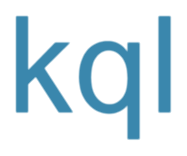

<IPython.core.display.Javascript object>

In [1]:
import warnings
warnings.filterwarnings("ignore", message="pkg_resources is deprecated", category=UserWarning)

# pip install Kqlmagic --upgrade
%reload_ext Kqlmagic
%kql adx://code;cluster='https://kvc-tahhe3at0ubkgsaxdn.southcentralus.kusto.windows.net';database='ADXFREE'

> ## overview

<pre style="background: transparent; padding: 0; margin: 0; font-family: 'JetBrains Mono', monospace; line-height: 1.25;">
mbx (reference list)                       CloudAppEvents
┌────────────────────┐                    ┌──────┬────────────────────┬─────────────┐
│ PrimarySmtpAddress │                    │ ...  │ UPN                │ ...         │
├────────────────────┤                    ├──────┼────────────────────┼─────────────┤
│ bob@contoso.com    │ ·················► │      │                    │             │
│ susan@contoso.com  │ ·················► │      │ bob@contoso.com    │             │
│ sam@contoso.com    │ ···· no match ···· │      │                    │             │
└────────────────────┘                    │      │ susan@contoso.com  │             │
                                          │      │ bob@contoso.com    │             │
                                          │      │                    │             │
                                          │      │                    │             │
                                          │      │ bob@contoso.com    │             │
                                          │      │                    │             │
                                          │      │ susan@contoso.com  │             │
                                          └──────┴────────────────────┴─────────────┘
                                                 │
                                                 │ sam@contoso.com never appears
                                                 │ 
                                                 ▼
                                      lookup kind=leftouter
                                                 │
                                                 ▼
                            ┌────────────────────┬──────────────────┐
                            │ PrimarySmtpAddress │ Status           │
                            ├────────────────────┼──────────────────┤
                            │ bob@contoso.com    │ Active           │  ← matched
                            │ susan@contoso.com  │ Active           │  ← matched
                            │ sam@contoso.com    │ Stale / Orphaned │  ← no rows found in CloudAppEvents
                            └────────────────────┴──────────────────┘
</pre>

> ## query concepts

<pre style="background: transparent; padding: 0; margin: 0; font-family: 'JetBrains Mono', monospace; line-height: 1.25;">
mbx (CSV)               CloudAppEvents (30 days, Exchange Online only)
┌────────────────────┐  ┌─────────────────────┬────────────────────┬──────────────────────────────────────────────────────────────┐
│ PrimarySmtpAddress │  │ Timestamp           │ ActionType         │ RawEventData                                                 │
├────────────────────┤  ├─────────────────────┼────────────────────┼──────────────────────────────────────────────────────────────┤
│ bob@contoso.com    │  │ 2026-04-28 10:22:00 │ MailItemsAccessed  │ {"MailboxOwnerUPN":"bob@contoso.com","UserId":"bob@..."}     │
│ susan@contoso.com  │  │ 2026-05-01 08:14:00 │ Send               │ {"MailboxOwnerUPN":"bob@contoso.com","UserId":"bob@..."}     │
│ sam@contoso.com    │  │ 2026-05-02 11:03:00 │ MoveToDeletedItems │ {"MailboxOwnerUPN":"bob@contoso.com","UserId":"bob@..."}     │
└────────────────────┘  │ 2026-04-01 09:45:00 │ MailItemsAccessed  │ {"MailboxOwnerUPN":"susan@contoso.com","UserId":"susan@..."} │
        │               │ ...                 │ ...                │ ...                                                          │
        │               └─────────────────────┴────────────────────┴──────────────────────────────────────────────────────────────┘
        │                                                          │
        │                                                          │ parse_json(RawEventData)
        │                                                          │ extend MailboxOwnerUPN, UserId
        │                                                          │ extend ResolvedUPN = case(...)
        │                                                          │ where ResolvedUPN in (mbx)
        │                                                          │ project ResolvedUPN, Timestamp, ActionType
        │                                                          │ summarize arg_max(Timestamp, ActionType) by ResolvedUPN
        │                                                          │
        │                                                          ▼
        │                           activeMailboxes (derived, one row per mailbox)
        │                           ┌───────────────────┬─────────────────────┬────────────────────┐
        │                           │ ResolvedUPN       │ LastSeen            │ LastOperation      │
        │                           ├───────────────────┼─────────────────────┼────────────────────┤
        │                           │ bob@contoso.com   │ 2026-05-02 11:03:00 │ MoveToDeletedItems │
        │                           │ susan@contoso.com │ 2026-04-01 09:45:00 │ MailItemsAccessed  │
        │                           └───────────────────┴─────────────────────┴────────────────────┘
        │                                                          │
        └──────────────────────────────────────────────────────────┘
                                    │
                                    │ lookup kind=leftouter
                                    │ mbx is left side — all CSV rows preserved
                                    │ sam@contoso.com has no match → null LastSeen
                                    │
                                    ▼
Final Result
┌────────────────────┬──────────────────┬─────────────────────┬────────────────────┐
│ PrimarySmtpAddress │ Status           │ LastSeen            │ LastOperation      │
├────────────────────┼──────────────────┼─────────────────────┼────────────────────┤
│ sam@contoso.com    │ Stale / Orphaned │ null                │ null               │  ← no match
│ susan@contoso.com  │ Active           │ 2026-04-01 09:45:00 │ MailItemsAccessed  │
│ bob@contoso.com    │ Active           │ 2026-05-02 11:03:00 │ MoveToDeletedItems │
└────────────────────┴──────────────────┴─────────────────────┴────────────────────┘
</pre>

> ## query for mailbox activity

### create reference list (table) in memory

In [2]:
%%kql
let mbx = datatable(PrimarySmtpAddress: string)
[
    "bob@contoso.com",
    "susan@contoso.com",
    "sam@contoso.com"
];
mbx

<IPython.core.display.Javascript object>

PrimarySmtpAddress
bob@contoso.com
susan@contoso.com
sam@contoso.com


[{'PrimarySmtpAddress': 'bob@contoso.com'},
 {'PrimarySmtpAddress': 'susan@contoso.com'},
 {'PrimarySmtpAddress': 'sam@contoso.com'}]

### read reference list from external source

In [3]:
%%kql
let mbx = materialize(                                                                       // caches the CSV result
    externaldata (PrimarySmtpAddress: string) [
    @"https://bwdemoblob.blob.core.windows.net/curated/bw_senders.csv"
    h@"?sp=r&st=2026-05-02T18:55:24Z&se=2026-05-03T03:10:24Z&spr=https&sv=2025-11-05&sr=b&sig=KcVXrj1fckh5hWN%2BQbwKMd3ym1TvCyedP3WhGeWzao4%3D"
    ]
    with (format='csv', ignorefirstrecord=true)
    | where PrimarySmtpAddress != "PrimarySmtpAddress"                                       // drop csv header row
    | project PrimarySmtpAddress = tolower(PrimarySmtpAddress)                               // normalize to lowercase for case-insensitive matching
    );
let activeMailboxes =
    CloudAppEvents
    | where Timestamp >= ago(30d)
    | where Application == "Microsoft Exchange Online"                                       // scope to Exchange only
    | extend Raw = parse_json(RawEventData)                                                  // parse JSON once into Raw and reuse
    | extend MailboxOwnerUPN = tostring(Raw.MailboxOwnerUPN)
    | extend UserId = tostring(Raw.UserId)
    | project-away Raw                                                                       // drop JSON; no longer needed
    | extend ResolvedUPN = tolower(case(
        isnotempty(MailboxOwnerUPN), MailboxOwnerUPN,                                        // prefer MailboxOwnerUPN — reflects the mailbox being acted upon
        isnotempty(UserId), UserId,                                                          // fall back to UserId if MailboxOwnerUPN is unpopulated
        ""
        ))
    | where isnotempty(ResolvedUPN)                                                          // drop rows where neither field was populated
    | where ResolvedUPN in (mbx)                                                             // prune to CSV mailboxes only
    | project ResolvedUPN, Timestamp, ActionType                                             // drop all other columns before aggregation
    | summarize arg_max(Timestamp, ActionType) by ResolvedUPN                                // arg_max finds the latest row and carries ActionType from it
    | project ResolvedUPN, LastSeen = Timestamp, LastOperation = ActionType;                 // rename for clean output
mbx
| lookup kind=leftouter activeMailboxes on $left.PrimarySmtpAddress == $right.ResolvedUPN    // leftouter preserves all CSV rows — unmatched rows appear as Stale / Orphaned
| extend Status = case(
    isnotempty(LastSeen), "Active",                                                          // LastSeen is null for unmatched rows — falls through to Stale / Orphaned
    "Stale / Orphaned"
    )
| project PrimarySmtpAddress, Status, LastSeen, LastOperation
| sort by Status asc, LastSeen asc                                                           // stale mailboxes sort to top, oldest activity first within Active

<IPython.core.display.Javascript object>

PrimarySmtpAddress,Status,LastSeen,LastOperation
james.reed@banwinner.com,Active,2026-04-29 21:24:03+00:00,MailItemsAccessed
grayson.ortiz@banwinner.com,Active,2026-04-30 18:49:02+00:00,MailItemsAccessed
david.white@banwinner.com,Active,2026-04-30 22:49:06+00:00,MailItemsAccessed
jessica.garcia@banwinner.com,Active,2026-05-01 09:54:03+00:00,MailItemsAccessed
eva.scott@banwinner.com,Active,2026-05-01 16:49:02+00:00,MailItemsAccessed
hannah.cox@banwinner.com,Active,2026-05-01 19:29:02+00:00,MailItemsAccessed
kendall.thomas@banwinner.com,Active,2026-05-01 19:29:02+00:00,MailItemsAccessed
connor.rodriguez@banwinner.com,Active,2026-05-01 20:14:01+00:00,MailItemsAccessed
james.green@banwinner.com,Active,2026-05-01 20:14:01+00:00,MailItemsAccessed
elena.anderson@banwinner.com,Active,2026-05-01 20:14:01+00:00,MailItemsAccessed


[{'PrimarySmtpAddress': 'james.reed@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 4, 29, 21, 24, 3, tzinfo=tzutc()), 'LastOperation': 'MailItemsAccessed'},
 {'PrimarySmtpAddress': 'grayson.ortiz@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 4, 30, 18, 49, 2, tzinfo=tzutc()), 'LastOperation': 'MailItemsAccessed'},
 {'PrimarySmtpAddress': 'david.white@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 4, 30, 22, 49, 6, tzinfo=tzutc()), 'LastOperation': 'MailItemsAccessed'},
 {'PrimarySmtpAddress': 'jessica.garcia@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 9, 54, 3, tzinfo=tzutc()), 'LastOperation': 'MailItemsAccessed'},
 {'PrimarySmtpAddress': 'eva.scott@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 16, 49, 2, tzinfo=tzutc()), 'LastOperation': 'MailItemsAccessed'},
 {'PrimarySmtpAddress': 'hannah.cox@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 19, 29, 2, tzinfo=tzutc()), 'LastOperation': 'MailItemsAccessed'},
 {'PrimarySmtpAddress': 'kendall.thomas@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 19, 29, 2, tzinfo=tzutc()), 'LastOperation': 'MailItemsAccessed'},
 {'PrimarySmtpAddress': 'connor.rodriguez@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 20, 14, 1, tzinfo=tzutc()), 'LastOperation': 'MailItemsAccessed'},
 {'PrimarySmtpAddress': 'james.green@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 20, 14, 1, tzinfo=tzutc()), 'LastOperation': 'MailItemsAccessed'},
 {'PrimarySmtpAddress': 'elena.anderson@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 20, 14, 1, tzinfo=tzutc()), 'LastOperation': 'MailItemsAccessed'},
 {'PrimarySmtpAddress': 'allison.morales@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 20, 14, 2, tzinfo=tzutc()), 'LastOperation': 'MailItemsAccessed'},
 {'PrimarySmtpAddress': 'alyssa.rodriguez@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 20, 14, 2, tzinfo=tzutc()), 'LastOperation': 'MailItemsAccessed'},
 {'PrimarySmtpAddress': 'kennedy.holmes@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 20, 24, 3, tzinfo=tzutc()), 'LastOperation': 'MailItemsAccessed'},
 {'PrimarySmtpAddress': 'violet.brooks@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 21, 24, 12, tzinfo=tzutc()), 'LastOperation': 'MailItemsAccessed'},
 {'PrimarySmtpAddress': 'olivia.jackson@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 21, 24, 15, tzinfo=tzutc()), 'LastOperation': 'MailItemsAccessed'},
 {'PrimarySmtpAddress': 'ava.rivera@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 22, 4, 1, tzinfo=tzutc()), 'LastOperation': 'MailItemsAccessed'},
 {'PrimarySmtpAddress': 'lillian.diaz@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 23, 3, 47, tzinfo=tzutc()), 'LastOperation': 'Send'},
 {'PrimarySmtpAddress': 'olivia.nelson@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 23, 9, 6, tzinfo=tzutc()), 'LastOperation': 'MailItemsAccessed'},
 {'PrimarySmtpAddress': 'luke.campbell@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 23, 9, 7, tzinfo=tzutc()), 'LastOperation': 'MailItemsAccessed'},
 {'PrimarySmtpAddress': 'quinn.jimenez@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 23, 9, 7, tzinfo=tzutc()), 'LastOperation': 'MailItemsAccessed'},
 {'PrimarySmtpAddress': 'reed.jones@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 23, 9, 8, tzinfo=tzutc()), 'LastOperation': 'MailItemsAccessed'},
 {'PrimarySmtpAddress': 'ian.evans@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 23, 9, 8, tzinfo=tzutc()), 'LastOperation': '

> ## query w/ watchlist

In [ ]:
%%kql
let mbx = materialize(
    _GetWatchlist('bw_senders')
    | project PrimarySmtpAddress = tolower(PrimarySmtpAddress)
    );
let activeMailboxes =
    CloudAppEvents
    | where TimeGenerated >= ago(30d)
    | where Application == "Microsoft Exchange Online"                                       // scope to Exchange only
    | extend Raw = parse_json(RawEventData)                                                  // parse JSON once into Raw and reuse
    | extend MailboxOwnerUPN = tostring(Raw.MailboxOwnerUPN)
    | extend UserId = tostring(Raw.UserId)
    | project-away Raw                                                                       // drop JSON; no longer needed
    | extend ResolvedUPN = tolower(case(
        isnotempty(MailboxOwnerUPN), MailboxOwnerUPN,                                        // prefer MailboxOwnerUPN — reflects the mailbox being acted upon
        isnotempty(UserId), UserId,                                                          // fall back to UserId if MailboxOwnerUPN is unpopulated
        ""
        ))
    | where isnotempty(ResolvedUPN)                                                          // drop rows where neither field was populated
    | where ResolvedUPN in (mbx)                                                             // prune to CSV mailboxes only
    | project ResolvedUPN, TimeGenerated, ActionType                                         // drop all other columns before aggregation
    | summarize arg_max(TimeGenerated, ActionType) by ResolvedUPN                            // arg_max finds the latest row and carries ActionType from it
    | project ResolvedUPN, LastSeen = TimeGenerated, LastOperation = ActionType;             // rename for clean output
mbx
| lookup kind=leftouter activeMailboxes on $left.PrimarySmtpAddress == $right.ResolvedUPN    // leftouter preserves all CSV rows — unmatched rows appear as Stale / Orphaned
| extend Status = case(
    isnotempty(LastSeen), "Active",                                                          // LastSeen is null for unmatched rows — falls through to Stale / Orphaned
    "Stale / Orphaned"
    )
| project PrimarySmtpAddress, Status, LastSeen, LastOperation
| sort by Status asc, LastSeen asc                                                           // stale mailboxes sort to top, oldest activity first within Active

> ## lightweight option w/ toscalar

only returns mailboxes with activity, no additional info

In [4]:
%%kql
let mbx_set = toscalar(
    externaldata (PrimarySmtpAddress: string) [
    @"https://bwdemoblob.blob.core.windows.net/curated/bw_senders.csv"
    h@"?sp=r&st=2026-05-02T18:55:24Z&se=2026-05-03T03:10:24Z&spr=https&sv=2025-11-05&sr=b&sig=KcVXrj1fckh5hWN%2BQbwKMd3ym1TvCyedP3WhGeWzao4%3D"
    ]
    with (format='csv', ignorefirstrecord=true)
    | where PrimarySmtpAddress != "PrimarySmtpAddress"                                       // drop header row
    | project PrimarySmtpAddress = tolower(PrimarySmtpAddress)                               // normalize to lowercase
    | summarize make_set(PrimarySmtpAddress)
    );
CloudAppEvents
| where Timestamp >= ago(30d)
| where Application == "Microsoft Exchange Online"                                           // scope to Exchange only
| extend Raw = parse_json(RawEventData)                                                      // parse JSON once into Raw and reuse
| extend MailboxOwnerUPN = tostring(Raw.MailboxOwnerUPN)
| extend UserId = tostring(Raw.UserId)
| project-away Raw                                                                           // drop JSON; no longer needed
| extend ResolvedUPN = tolower(case(
    isnotempty(MailboxOwnerUPN), MailboxOwnerUPN,                                            // prefer MailboxOwnerUPN — reflects the mailbox being acted upon
    isnotempty(UserId), UserId,                                                              // fall back to UserId if MailboxOwnerUPN is unpopulated
    ""
    ))
| where isnotempty(ResolvedUPN)                                                              // drop rows where neither field was populated
| where ResolvedUPN in (mbx_set)                                                             // prune to CSV mailboxes only
| project ResolvedUPN                                                                        // drop all remaining columns — only ResolvedUPN needed
| distinct ResolvedUPN                                                                       // one row per active mailbox
// | summarize EventCount = count() by ResolvedUPN

<IPython.core.display.Javascript object>

ResolvedUPN
sawyer.ross@banwinner.com
hadley.sanchez@banwinner.com
allison.palmer@banwinner.com
abigail.davis@banwinner.com
leah.wilson@banwinner.com
logan.walker@banwinner.com
sofia.fernandez@banwinner.com
anthony.carroll@banwinner.com
gabriel.walker@banwinner.com
jane.thomas@banwinner.com


[{'ResolvedUPN': 'sawyer.ross@banwinner.com'},
 {'ResolvedUPN': 'hadley.sanchez@banwinner.com'},
 {'ResolvedUPN': 'allison.palmer@banwinner.com'},
 {'ResolvedUPN': 'abigail.davis@banwinner.com'},
 {'ResolvedUPN': 'leah.wilson@banwinner.com'},
 {'ResolvedUPN': 'logan.walker@banwinner.com'},
 {'ResolvedUPN': 'sofia.fernandez@banwinner.com'},
 {'ResolvedUPN': 'anthony.carroll@banwinner.com'},
 {'ResolvedUPN': 'gabriel.walker@banwinner.com'},
 {'ResolvedUPN': 'jane.thomas@banwinner.com'},
 {'ResolvedUPN': 'quinn.jimenez@banwinner.com'},
 {'ResolvedUPN': 'nora.sullivan@banwinner.com'},
 {'ResolvedUPN': 'ian.evans@banwinner.com'},
 {'ResolvedUPN': 'ian.palmer@banwinner.com'},
 {'ResolvedUPN': 'ethan.rogers@banwinner.com'},
 {'ResolvedUPN': 'luke.campbell@banwinner.com'},
 {'ResolvedUPN': 'nora.phillips@banwinner.com'},
 {'ResolvedUPN': 'alexander.foster@banwinner.com'},
 {'ResolvedUPN': 'presley.reynolds@banwinner.com'},
 {'ResolvedUPN': 'hudson.perez@banwinner.com'},
 {'ResolvedUPN': 'reed.jones@banwinner.com'},
 {'ResolvedUPN': 'paisley.harris@banwinner.com'},
 {'ResolvedUPN': 'ruby.williams@banwinner.com'},
 {'ResolvedUPN': 'oliver.collins@banwinner.com'},
 {'ResolvedUPN': 'carter.bailey@banwinner.com'},
 {'ResolvedUPN': 'elena.ferguson@banwinner.com'},
 {'ResolvedUPN': 'anthony.smith@banwinner.com'},
 {'ResolvedUPN': 'alice.stewart@banwinner.com'},
 {'ResolvedUPN': 'olivia.nelson@banwinner.com'},
 {'ResolvedUPN': 'max.coleman@banwinner.com'},
 {'ResolvedUPN': 'aubrey.nelson@banwinner.com'},
 {'ResolvedUPN': 'gabriel.hunt@banwinner.com'},
 {'ResolvedUPN': 'mila.butler@banwinner.com'},
 {'ResolvedUPN': 'alexander.rivera@banwinner.com'},
 {'ResolvedUPN': 'brady.bailey@banwinner.com'},
 {'ResolvedUPN': 'liam.white@banwinner.com'},
 {'ResolvedUPN': 'stella.bell@banwinner.com'},
 {'ResolvedUPN': 'hailey.reynolds@banwinner.com'},
 {'ResolvedUPN': 'zoe.henderson@banwinner.com'},
 {'ResolvedUPN': 'max.patterson@banwinner.com'},
 {'ResolvedUPN': 'luke.turner@banwinner.com'},
 {'ResolvedUPN': 'lucy.richardson@banwinner.com'},
 {'ResolvedUPN': 'emily.harris@banwinner.com'},
 {'ResolvedUPN': 'tanner.barnes@banwinner.com'},
 {'ResolvedUPN': 'savannah.price@banwinner.com'},
 {'ResolvedUPN': 'ellis.hernandez@banwinner.com'},
 {'ResolvedUPN': 'isaiah.morales@banwinner.com'},
 {'ResolvedUPN': 'luke.brown@banwinner.com'},
 {'ResolvedUPN': 'sawyer.jenkins@banwinner.com'},
 {'ResolvedUPN': 'anna.anderson@banwinner.com'},
 {'ResolvedUPN': 'luna.hunt@banwinner.com'},
 {'ResolvedUPN': 'walker.lawson@banwinner.com'},
 {'ResolvedUPN': 'benjamin.young@banwinner.com'},
 {'ResolvedUPN': 'lillian.freeman@banwinner.com'},
 {'ResolvedUPN': 'wyatt.lee@banwinner.com'},
 {'ResolvedUPN': 'taylor.morgan@banwinner.com'},
 {'ResolvedUPN': 'riley.hernandez@banwinner.com'},
 {'ResolvedUPN': 'natalie.stewart@banwinner.com'},
 {'ResolvedUPN': 'oliver.white@banwinner.com'},
 {'ResolvedUPN': 'lucas.thomas@banwinner.com'},
 {'ResolvedUPN': 'wyatt.torres@banwinner.com'},
 {'ResolvedUPN': 'sarah.thompson@banwinner.com'},
 {'ResolvedUPN': 'carson.adams@banwinner.com'},
 {'ResolvedUPN': 'jeremiah.jackson@banwinner.com'},
 {'ResolvedUPN': 'claire.hughes@banwinner.com'},
 {'ResolvedUPN': 'sydney.king@banwinner.com'},
 {'ResolvedUPN': 'christopher.vasquez@banwinner.com'},
 {'ResolvedUPN': 'oliver.chapman@banwinner.com'},
 {'ResolvedUPN': 'scarlett.hill@banwinner.com'},
 {'ResolvedUPN': 'isla.king@banwinner.com'},
 {'ResolvedUPN': 'aaliyah.west@banwinner.com'},
 {'ResolvedUPN': 'alyssa.nichols@banwinner.com'},
 {'ResolvedUPN': 'morgan.stone@banwinner.com'},
 {'ResolvedUPN': 'charles.graham@banwinner.com'},
 {'ResolvedUPN': 'makayla.daniels@banwinner.com'},
 {'ResolvedUPN': 'andrew.alvarez@banwinner.com'},
 {'ResolvedUPN': 'noah.sanders@banwinner.com'},
 {'ResolvedUPN': 'elena.martinez@banwinner.com'},
 {'ResolvedUPN': 'alexa.nelson@banwinner.com'},
 {'ResolvedUPN': 'olivia.jackson@banwinner.com'},
 {'ResolvedUPN': 'robert.henderson@banwinner.com'},
 {'ResolvedUPN': 'lillian.lewis@b

> ## query for mailbox traffic

In [5]:
%%kql
let mbx = materialize(
    externaldata (PrimarySmtpAddress: string) [
    @"https://bwdemoblob.blob.core.windows.net/curated/bw_senders.csv"
    h@"?sp=r&st=2026-05-02T18:55:24Z&se=2026-05-03T03:10:24Z&spr=https&sv=2025-11-05&sr=b&sig=KcVXrj1fckh5hWN%2BQbwKMd3ym1TvCyedP3WhGeWzao4%3D"
    ]
    with (format='csv', ignorefirstrecord=true)
    | where PrimarySmtpAddress != "PrimarySmtpAddress"
    | project PrimarySmtpAddress = tolower(PrimarySmtpAddress)
    );
let activeMailboxes =
    EmailEvents
    | where Timestamp >= ago(30d)
    | extend RecipientEmailAddress = tolower(RecipientEmailAddress)
    | where RecipientEmailAddress in (mbx)
    | project RecipientEmailAddress, Timestamp
    | summarize LastSeen = max(Timestamp) by RecipientEmailAddress
    | project RecipientEmailAddress, LastSeen;
mbx
| lookup kind=leftouter activeMailboxes on $left.PrimarySmtpAddress == $right.RecipientEmailAddress
| extend Status = case(
    isnotempty(LastSeen), "Active",
    "Stale / Orphaned"
    )
| project PrimarySmtpAddress, Status, LastSeen
| sort by Status asc, LastSeen asc

<IPython.core.display.Javascript object>

PrimarySmtpAddress,Status,LastSeen
david.white@banwinner.com,Active,2026-05-01 19:20:54+00:00
hannah.cox@banwinner.com,Active,2026-05-01 19:20:54+00:00
kendall.thomas@banwinner.com,Active,2026-05-01 19:20:54+00:00
allison.morales@banwinner.com,Active,2026-05-01 20:05:49+00:00
connor.rodriguez@banwinner.com,Active,2026-05-01 20:05:49+00:00
alyssa.rodriguez@banwinner.com,Active,2026-05-01 20:05:49+00:00
elena.anderson@banwinner.com,Active,2026-05-01 20:05:49+00:00
avery.lewis@banwinner.com,Active,2026-05-01 20:05:50+00:00
james.green@banwinner.com,Active,2026-05-01 20:05:51+00:00
kennedy.holmes@banwinner.com,Active,2026-05-01 20:19:51+00:00


[{'PrimarySmtpAddress': 'david.white@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 19, 20, 54, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'hannah.cox@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 19, 20, 54, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'kendall.thomas@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 19, 20, 54, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'allison.morales@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 20, 5, 49, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'connor.rodriguez@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 20, 5, 49, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'alyssa.rodriguez@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 20, 5, 49, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'elena.anderson@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 20, 5, 49, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'avery.lewis@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 20, 5, 50, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'james.green@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 20, 5, 51, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'kennedy.holmes@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 20, 19, 51, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'lillian.diaz@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 21, 42, 53, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'grayson.ortiz@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 21, 49, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'ava.rivera@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 21, 58, 55, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'ian.evans@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 23, 2, 37, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'olivia.nelson@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 23, 2, 38, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'luke.campbell@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 23, 2, 38, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'reed.jones@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 23, 2, 38, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'christopher.king@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 23, 2, 38, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'quinn.jimenez@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 23, 2, 41, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'emma.fuller@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 23, 13, 58, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'aurora.carter@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 23, 13, 59, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'penelope.lawson@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 2, 0, 21, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'emily.walker@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 2, 0, 21, 1, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'kevin.jackson@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 2, 0, 21, 7, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'hazel.chavez@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 2, 0, 21, 12, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'stella.campbell@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 2, 1, 15, 53, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'josiah.diaz@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 2, 1, 15, 53, tzinfo=tzutc())},
 {'PrimarySmtpAddress': 'mila.hughes@banwinner.com', 'Status': 'Act

> ## query for group mail traffic

In [6]:
%%kql
let groups = materialize(
    externaldata (PrimarySmtpAddress: string) [
    @"https://bwdemoblob.blob.core.windows.net/curated/bw_groups.csv"
    h@"?sp=r&st=2026-05-02T20:52:03Z&se=2026-05-03T05:07:03Z&spr=https&sv=2025-11-05&sr=b&sig=dMh1VYEzZ4WO1oJOtGHLwLiJ%2ByjY2fqup%2BnX9tXKaeM%3D"
    ]
    with (format='csv', ignorefirstrecord=true)
    | where PrimarySmtpAddress != "PrimarySmtpAddress"
    | project PrimarySmtpAddress = tolower(PrimarySmtpAddress)
    );
let activeGroups =
    EmailEvents
    | where Timestamp >= ago(30d)
    | extend DistributionList = tolower(DistributionList)
    | where DistributionList in (groups)
    | project DistributionList, Timestamp
    | summarize LastSeen = max(Timestamp) by DistributionList
    | project DistributionList, LastSeen;
groups
| lookup kind=leftouter activeGroups on $left.PrimarySmtpAddress == $right.DistributionList
| extend Status = case(
    isnotempty(LastSeen), "Active",
    "Stale / Orphaned"
    )
| project GroupSmtpAddress = PrimarySmtpAddress, Status, LastSeen
| sort by Status asc, LastSeen asc

<IPython.core.display.Javascript object>

GroupSmtpAddress,Status,LastSeen
_sg_human_resources@banwinner.com,Active,2026-05-01 19:20:54+00:00
_sg_executive_leadership@banwinner.com,Active,2026-05-01 20:05:52+00:00
_sg_sales@banwinner.com,Active,2026-05-01 23:02:46+00:00
_sg_field_services@banwinner.com,Active,2026-05-01 23:14:02+00:00
_sg_legal@banwinner.com,Active,2026-05-02 00:21:09+00:00
_sg_engineering@banwinner.com,Active,2026-05-02 01:16:02+00:00
_sg_training_development@banwinner.com,Active,2026-05-02 06:01:51+00:00
_sg_compliance@banwinner.com,Active,2026-05-02 10:13:59+00:00
_sg_facilities@banwinner.com,Active,2026-05-02 14:50:21+00:00
_sg_customer_support@banwinner.com,Active,2026-05-02 14:58:09+00:00


[{'GroupSmtpAddress': '_sg_human_resources@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 19, 20, 54, tzinfo=tzutc())},
 {'GroupSmtpAddress': '_sg_executive_leadership@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 20, 5, 52, tzinfo=tzutc())},
 {'GroupSmtpAddress': '_sg_sales@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 23, 2, 46, tzinfo=tzutc())},
 {'GroupSmtpAddress': '_sg_field_services@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 1, 23, 14, 2, tzinfo=tzutc())},
 {'GroupSmtpAddress': '_sg_legal@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 2, 0, 21, 9, tzinfo=tzutc())},
 {'GroupSmtpAddress': '_sg_engineering@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 2, 1, 16, 2, tzinfo=tzutc())},
 {'GroupSmtpAddress': '_sg_training_development@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 2, 6, 1, 51, tzinfo=tzutc())},
 {'GroupSmtpAddress': '_sg_compliance@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 2, 10, 13, 59, tzinfo=tzutc())},
 {'GroupSmtpAddress': '_sg_facilities@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 2, 14, 50, 21, tzinfo=tzutc())},
 {'GroupSmtpAddress': '_sg_customer_support@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 2, 14, 58, 9, tzinfo=tzutc())},
 {'GroupSmtpAddress': '_sg_administration@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 2, 16, 1, tzinfo=tzutc())},
 {'GroupSmtpAddress': '_sg_procurement@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 2, 16, 3, 24, tzinfo=tzutc())},
 {'GroupSmtpAddress': '_sg_product_management@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 2, 17, 4, 6, tzinfo=tzutc())},
 {'GroupSmtpAddress': '_sg_information_technology@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 2, 17, 26, tzinfo=tzutc())},
 {'GroupSmtpAddress': '_sg_business_development@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 2, 18, 10, 12, tzinfo=tzutc())},
 {'GroupSmtpAddress': '_sg_operations@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 2, 18, 47, 13, tzinfo=tzutc())},
 {'GroupSmtpAddress': '_sg_marketing@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 2, 20, 1, 3, tzinfo=tzutc())},
 {'GroupSmtpAddress': '_sg_finance@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 2, 20, 43, 39, tzinfo=tzutc())},
 {'GroupSmtpAddress': '_sg_quality_assurance@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 2, 20, 43, 42, tzinfo=tzutc())},
 {'GroupSmtpAddress': '_sg_research_innovation@banwinner.com', 'Status': 'Active', 'LastSeen': datetime.datetime(2026, 5, 2, 21, 49, 30, tzinfo=tzutc())},
 {'GroupSmtpAddress': '_sg_cloudcreated@banwinner.com', 'Status': 'Stale / Orphaned', 'LastSeen': None},
 {'GroupSmtpAddress': '_dg_all@banwinner.com', 'Status': 'Stale / Orphaned', 'LastSeen': None},
 {'GroupSmtpAddress': '_dg_onprem@banwinner.com', 'Status': 'Stale / Orphaned', 'LastSeen': None},
 {'GroupSmtpAddress': '_sg_all@banwinner.com', 'Status': 'Stale / Orphaned', 'LastSeen': None},
 {'GroupSmtpAddress': '_sg_cloud@banwinner.com', 'Status': 'Stale / Orphaned', 'LastSeen': None},
 {'GroupSmtpAddress': '_sg_onprem@banwinner.com', 'Status': 'Stale / Orphaned', 'LastSeen': None},
 {'GroupSmtpAddress': '_dg_cloud@banwinner.com', 'Status': 'Stale / Orphaned', 'LastSeen': None},
 {'GroupSmtpAddress': 'sales@banwinner.com', 'Status': 'Stale / Orphaned', 'LastSeen': None},
 {'GroupSmtpAddress': '_dg_testshared@banwinner.com', 'Status': 'Stale / Orphaned', 'LastSeen': None},
 {'GroupSmtpAddress': '_sg_gbl@banwinner.onmicrosoft.com', 'Status': 'Stale / Orphaned', 'LastSeen': None},
 {'GroupSmtpAddress': '_sg_aiptest@